In [1]:
import pypsa
import numpy as np
import pandas as pd
import xarray as xr
import atlite
import yaml
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Get the root directory (where you're running the notebook)
root = Path.cwd()
pypsa_eur_root = root.parent.parent      # scripts/_testing/ → scripts/ → pypsa-eur/
home_root = pypsa_eur_root.parent        # pypsa-eur/ → /home/lois/pypsa-eur/
mscthesis_root = home_root / "mscthesis"
pypsa_dmg_root = home_root / "pypsa-damage"
pypsa_eur_scripts = pypsa_eur_root / "scripts"

In [2]:
home_root

PosixPath('/home/lois/pypsa-eur')

In [3]:
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))
sys.path.insert(0, str(pypsa_eur_root))
sys.path

['/home/lois/pypsa-eur/pypsa-eur',
 '/home/lois/pypsa-eur/pypsa-eur/scripts/_testing',
 '/home/lois/pypsa-eur/pypsa-eur/scripts',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python313.zip',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages']

## Plotting damage profiles

In [4]:
from plot_damage import (
    iplot_plant_profile,
    iplot_bus_profile,
    iplot_vulnerability_table,
    plot_plant_profile,
    plot_bus_profile,
    plot_vulnerability_table,
)
from styles import _DAMAGE_COLORS

from builders import build_plant_damage_df, build_bus_damage_df
from scripts.build_damage_profiles.build_nuclear_damage_profiles import load_nuclear_plants

# ── SCENARIO SELECTION ───────────────────────────────────────────────────────
# Set to any path under resources/ — both formats work:
#   "2022-FR/2022-FR-nucl_dmg_cap"
#   "FR-weather_years+dmg/weather_year_2018_nuc_cap"
SCENARIO_DIR = "2022-FR/weather_year_2022_nuc_cap"
CLUSTERS = 5

# ── Load ─────────────────────────────────────────────────────────────────────
import re

_resources = pypsa_eur_root / "resources" / SCENARIO_DIR

_year_match = re.search(r"\d{4}", Path(SCENARIO_DIR).name)
_year = int(_year_match.group()) if _year_match else None
cutout_path = (
    pypsa_eur_root / "data/cutout/build/unknown"
    / f"europe-{_year}-era5_fg10_lmlt.nc"
)

cutout_data = atlite.Cutout(path=cutout_path).data

powerplants_df = load_nuclear_plants(_resources / f"powerplants_s_{CLUSTERS}.csv", dateout_cutoff=2017)

plant_nc  = _resources / "damage_profiles" / "nuclear_damage_plants.nc"
damage_df = xr.open_dataset(plant_nc)["profile"].to_pandas()
damage_df = damage_df[damage_df.index.month.isin([6, 7, 8])]

print(f"Scenario : {SCENARIO_DIR}")
print(f"Cutout   : {cutout_path.name}")
print(f"Time     : {damage_df.index[0]}  →  {damage_df.index[-1]}")
print(f"Buses    : {sorted(powerplants_df['bus'].unique())}")


Scenario : 2022-FR/weather_year_2022_nuc_cap
Cutout   : europe-2022-era5_fg10_lmlt.nc
Time     : 2022-06-01 00:00:00  →  2022-08-31 23:00:00
Buses    : ['FR0 0', 'FR0 1', 'FR0 2', 'FR0 3', 'FR0 4']


In [5]:
plant_nc

PosixPath('/home/lois/pypsa-eur/pypsa-eur/resources/2022-FR/weather_year_2022_nuc_cap/damage_profiles/nuclear_damage_plants.nc')

In [5]:
powerplants_df

,Name,lat,lon,Capacity,bus
38,Nogent,48.5171,3.51810,2620.0,FR0 1
39,Paluel 2,49.8582,0.63540,5320.0,FR0 1
40,Penly 3,49.9764,1.21070,2660.0,FR0 1
41,St Alban,45.4043,4.75540,2670.0,FR0 3
42,Tricastin 2,44.3311,4.73110,3660.0,FR0 3
43,St Laurent 4,47.7197,1.57830,1830.0,FR0 1
44,Dampierre 5,47.7321,2.51850,3560.0,FR0 1
45,Belleville 6,47.5103,2.87501,2620.0,FR0 1
46,Gravelines 7,51.0141,2.13320,5460.0,FR0 1
47,Bugey 3,45.7973,5.27060,3580.0,FR0 3


In [6]:
damage_df

plant,Nogent,Paluel 2,Penly 3,St Alban,Tricastin 2,St Laurent 4,Dampierre 5,Belleville 6,Gravelines 7,Bugey 3,Cattenom,Chinon,Chooz 2,Civaux,Cruas 4,Fessenheim 3,Flamanville 2,Golfech 2,Blayais 3
time,,,,,,,,,,,,,,,,,,,
2022-06-01 00:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.001774,0.000000
2022-06-01 01:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.001037,0.000000
2022-06-01 02:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000301,0.000000
2022-06-01 03:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
2022-06-01 04:00:00,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-31 19:00:00,0.026173,0.0,0.0,0.0,0.001100,0.002810,0.002123,0.003256,0.0,0.0,0.0,0.009112,0.0,0.009362,0.0,0.017000,0.0,0.103236,0.096721
2022-08-31 20:00:00,0.023989,0.0,0.0,0.0,0.000813,0.002641,0.001892,0.002841,0.0,0.0,0.0,0.008760,0.0,0.008835,0.0,0.016135,0.0,0.098289,0.093886
2022-08-31 21:00:00,0.021264,0.0,0.0,0.0,0.000526,0.002417,0.001618,0.002529,0.0,0.0,0.0,0.008435,0.0,0.008398,0.0,0.015286,0.0,0.093584,0.090930


In [8]:
# Single plant
fig = iplot_plant_profile(build_plant_damage_df("Golfech 2", damage_df, cutout_data, powerplants_df))
fig.show()

In [29]:
# Bus — individual lines per plant
fig = iplot_bus_profile(build_bus_damage_df("FR0 2", damage_df, cutout_data, powerplants_df, mode="individual"))
fig.show()

In [31]:
# Bus — individual lines per plant
fig = iplot_bus_profile(build_bus_damage_df("FR0 3", damage_df, cutout_data, powerplants_df, mode="individual"))
fig.show()

In [32]:
# Bus — capacity-weighted aggregate
fig = iplot_bus_profile(build_bus_damage_df("FR0 2", damage_df, cutout_data, powerplants_df, mode="aggregate"))
fig.show()

In [33]:
# Bus — capacity-weighted aggregate
fig = iplot_bus_profile(build_bus_damage_df("FR0 3", damage_df, cutout_data, powerplants_df, mode="aggregate"))
fig.show()

In [ ]:
# Vulnerability lookup table
fig = iplot_vulnerability_table()
fig.show()

## Matplotlib versions (for reports)

Same data, same colour scheme, returns `fig, axes` for full export control.
E.g. `fig.savefig("output.pdf", dpi=300, bbox_inches="tight")`

In [ ]:
# Matplotlib versions are imported from plot_damage in the cell above

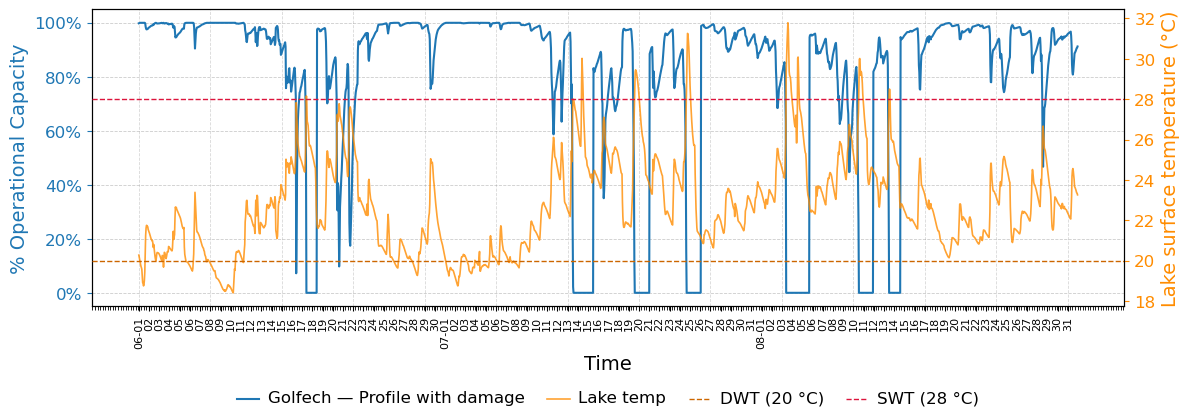

In [5]:
fig, axes = plot_plant_profile(
    build_plant_damage_df("Golfech 2", damage_df, cutout_data, powerplants_df),
    title="Golfech — Profile with damage",
    show_thresholds=True,
)
ax1, ax2 = axes

ax1.yaxis.grid(True, linestyle="--", alpha=0.4, color="grey", linewidth=0.6)
ax1.set_axisbelow(True)

weekly_ticks = pd.date_range(
    start=damage_df.index[0].normalize(),
    end=damage_df.index[-1],
    freq="7D",
)
for t in weekly_ticks:
    ax1.axvline(t, color="grey", linestyle="--", alpha=0.3, linewidth=0.6)

for ax in axes:
    leg = ax.get_legend()
    if leg:
        for text in leg.get_texts():
            text.set_fontsize(12)
        leg.set_bbox_to_anchor((0.5, -0.25))
plt.show()


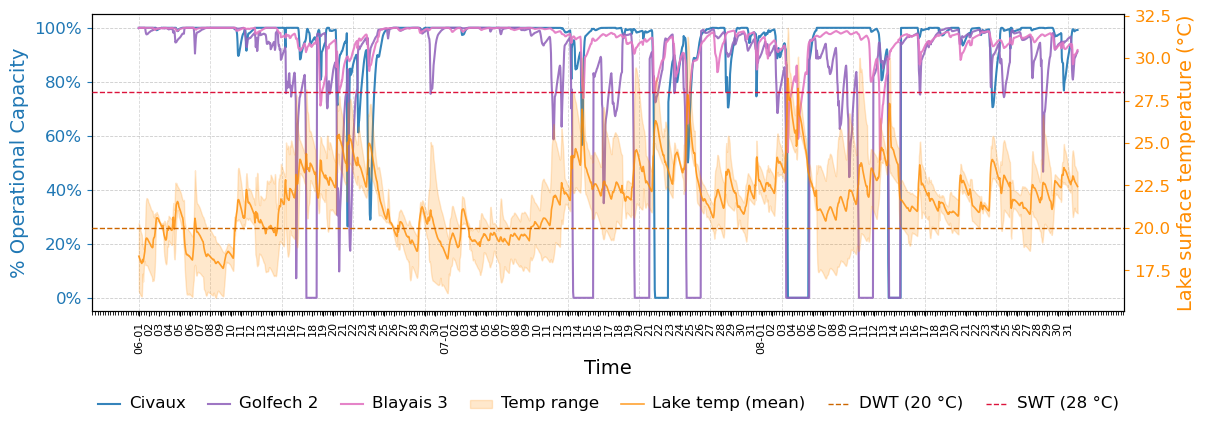

In [6]:
fig, axes = plot_bus_profile(
    build_bus_damage_df("FR0 2", damage_df, cutout_data, powerplants_df, mode="individual")
)
ax1, ax2 = axes

ax1.yaxis.grid(True, linestyle="--", alpha=0.4, color="grey", linewidth=0.6)
ax1.set_axisbelow(True)

weekly_ticks = pd.date_range(
    start=damage_df.index[0].normalize(),
    end=damage_df.index[-1],
    freq="7D",
)
for t in weekly_ticks:
    ax1.axvline(t, color="grey", linestyle="--", alpha=0.3, linewidth=0.6)

for ax in axes:
    leg = ax.get_legend()
    if leg:
        for text in leg.get_texts():
            text.set_fontsize(12)
        leg.set_bbox_to_anchor((0.5, -0.25))
plt.show()


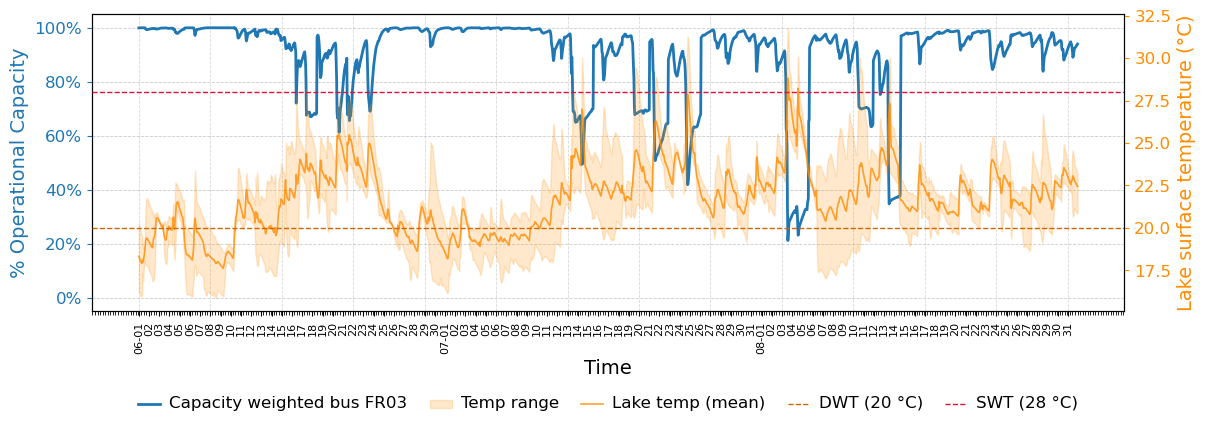

In [8]:
fig, axes = plot_bus_profile(
    build_bus_damage_df("FR0 2", damage_df, cutout_data, powerplants_df, mode="aggregate"),
    title="bus FR03",
)
ax1, ax2 = axes

ax1.yaxis.grid(True, linestyle="--", alpha=0.4, color="grey", linewidth=0.6)
ax1.set_axisbelow(True)

weekly_ticks = pd.date_range(
    start=damage_df.index[0].normalize(),
    end=damage_df.index[-1],
    freq="7D",
)
for t in weekly_ticks:
    ax1.axvline(t, color="grey", linestyle="--", alpha=0.3, linewidth=0.6)

for ax in axes:
    leg = ax.get_legend()
    if leg:
        for text in leg.get_texts():
            text.set_fontsize(12)
        leg.set_bbox_to_anchor((0.5, -0.25))
plt.show()


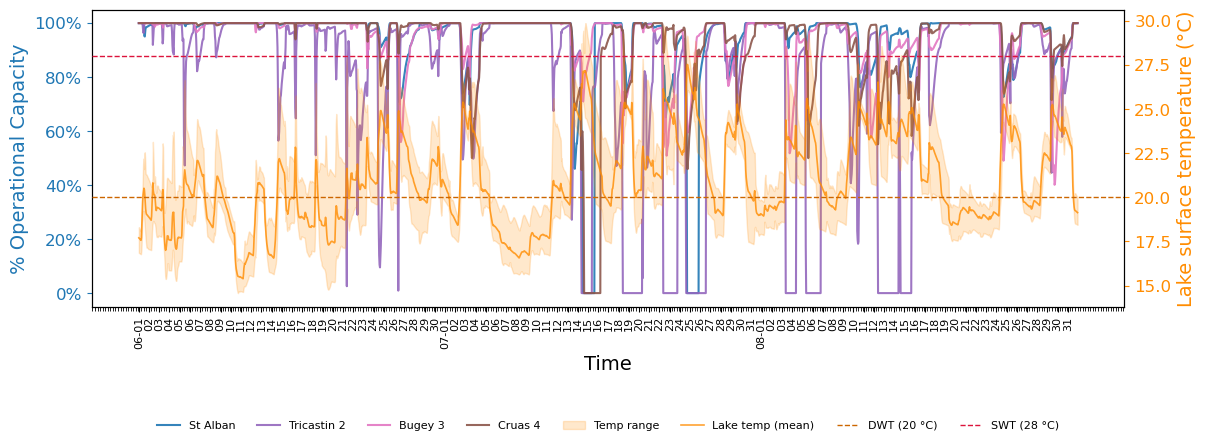

In [9]:
# Bus — individual lines per plant
fig, axes = plot_bus_profile(build_bus_damage_df("FR0 3", damage_df, cutout_data, powerplants_df, mode="individual"))
plt.show()

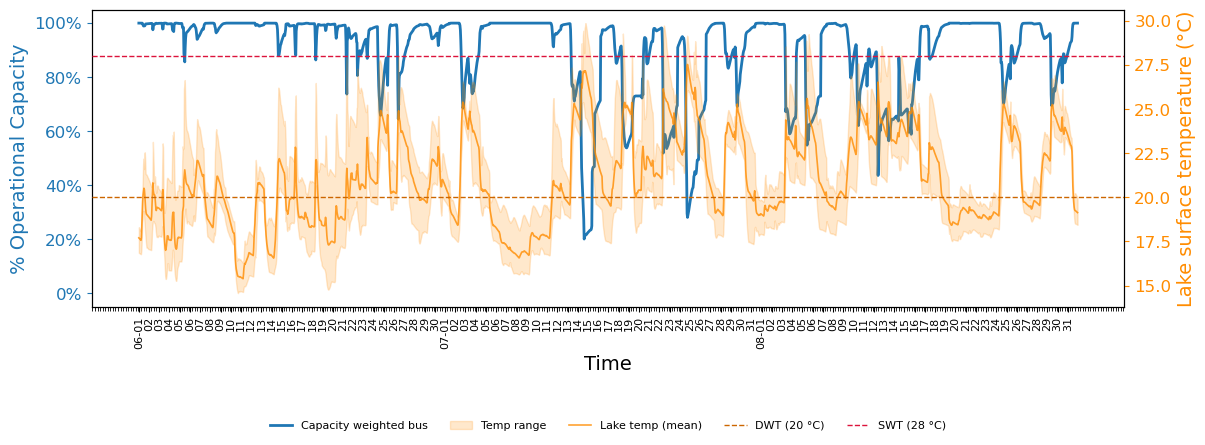

In [10]:
# Bus — individual lines per plant
fig, axes = plot_bus_profile(build_bus_damage_df("FR0 3", damage_df, cutout_data, powerplants_df, mode="aggregate"))
plt.show()

In [ ]:
# Vulnerability lookup table
fig, ax = plot_vulnerability_table()
plt.show()

In [8]:
from styles import (
    _SCRIPT_DIR,
    _DAMAGE_COLORS,
    _DAMAGE_SINGLE_COLOR,
    _TEMP_LINE_COLOR,
    _TEMP_BAND_FILL_RGBA,
    _DWT_COLOR,
    _SWT_COLOR,
    _DWT_C,
    _SWT_C,
    _compute_day_ticks,
)

_VULN_CSV = _SCRIPT_DIR.parent / "build_damage_profiles" / "water_temperature_vulnerability.csv"


In [5]:

import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.ticker as mticker

In [13]:
def plot_damage_components(
    figsize: tuple = (15, 5),
    legend_fontsize: int = 12,
    c: float = 1.0,
    swt_c: float | None = None,
) -> tuple:
    """
    Three-panel availability vs temperature decomposing the nuclear damage model.

    Panel 1 — Thermal derating: availability = 1 - vulnerability(T - DWT).
    Panel 2 — Regulatory shutdown: availability from water_temperature_regulations.csv
               (steep ramp from 1.0 to 0.0 over the 5°C window below SWT).
    Panel 3 — Combined: minimum availability (maximum damage) across both mechanisms.

    Parameters
    ----------
    c : float
        Vulnerability compression factor. c=1.0 shows only the base curve.
        Any other value overlays the compressed curve on panels 1 and 3.

    Returns
    -------
    fig, axes  (plt.Figure, ndarray of 3 Axes)
    """
    _C_COLOR = "#ff7f0e"

    df = pd.read_csv(_VULN_CSV)
    thresholds = df["threshold"].values.astype(float)
    vulns      = df["vulnerability"].values
    max_thresh = float(thresholds.max())  # 17

    df_reg         = pd.read_csv(_VULN_CSV.parent / "water_temperature_regulations.csv")
    reg_thresholds = df_reg["threshold"].values.astype(float)  # 0→5 (degrees below SWT)
    reg_values     = df_reg["regulation"].values               # 1.0→0.0

    dwt = _DWT_C
    swt = swt = swt_c if swt_c is not None else _SWT_C

    T_low  = dwt - 6
    T_high = dwt + max_thresh + 3
    T = np.linspace(T_low, T_high, 1000)

    avail_derate     = np.where(
        T <= dwt, 1.0,
        1.0 - np.interp(T - dwt, thresholds, vulns),
    )
    deg_below_swt    = np.clip(swt - T, 0, 5)
    avail_regulation = 1.0 - np.interp(deg_below_swt, reg_thresholds, reg_values)
    avail_combined   = np.minimum(avail_derate, avail_regulation)

    avail_derate_c   = None
    avail_combined_c = None
    if c != 1.0:
        avail_derate_c = np.where(
            T <= dwt, 1.0,
            1.0 - np.interp(np.clip((T - dwt) * c, 0, 17), thresholds, vulns),
        )
        avail_combined_c = np.minimum(avail_derate_c, avail_regulation)

    panels = [
        (avail_derate,     "(a) Derating from cooling efficiency",      [dwt], [],    True,  avail_derate_c),
        (avail_regulation, "(b) Shutdown from temperature regulations",  [],    [swt], True,  None),
        (avail_combined,   "(c) Combined",                               [dwt], [swt], False, avail_combined_c),
    ]

    n_legend_rows = 1 + (1 if c != 1.0 else 0)
    title_pad = int(legend_fontsize * (n_legend_rows * 2.0 + 0.5) + 10)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, (avail, title, dwt_marks, swt_marks, show_legend, avail_c) in zip(axes, panels):
        ax.fill_between(T, avail, color=_DAMAGE_SINGLE_COLOR, alpha=0.35, linewidth=0)
        ax.plot(T, avail, color=_DAMAGE_SINGLE_COLOR, linewidth=1.5)

        if avail_c is not None:
            ax.fill_between(T, avail_c, color=_C_COLOR, alpha=0.20, linewidth=0)
            ax.plot(T, avail_c, color=_C_COLOR, linewidth=1.5, linestyle="--")

        ax.set_xlim(T_low, T_high)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel("Water Temperature (°C)")
        ax.set_title(title, pad=title_pad)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.grid(axis="y", linewidth=0.5, alpha=0.4)

        for v in dwt_marks:
            ax.axvline(v, color=_DWT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)
        for v in swt_marks:
            ax.axvline(v, color=_SWT_COLOR, linestyle="--", linewidth=1.0, alpha=0.7)

        step = 4
        reg_ticks = np.arange(int(np.ceil(T_low / step)) * step, int(T_high) + step, step)
        all_ticks = sorted(set(reg_ticks.tolist()) | {round(v) for v in dwt_marks + swt_marks})

        ax.set_xticks(all_ticks)
        lbl_objs = ax.set_xticklabels([f"{v:.0f}" for v in all_ticks], ha="center")

        for lbl, val in zip(lbl_objs, all_ticks):
            if any(abs(val - v) < 0.5 for v in dwt_marks):
                lbl.set_color(_DWT_COLOR)
            elif any(abs(val - v) < 0.5 for v in swt_marks):
                lbl.set_color(_SWT_COLOR)

        handles = []
        if dwt_marks:
            handles.append(mlines.Line2D([0], [0], color=_DWT_COLOR, linestyle="--",
                                         linewidth=1.0, label="Desired Water Temperature"))
        if swt_marks:
            handles.append(mlines.Line2D([0], [0], color=_SWT_COLOR, linestyle="--",
                                         linewidth=1.0, label="Shutdown Water Temperature"))
        if avail_c is not None:
            handles.append(mlines.Line2D([0], [0], color=_C_COLOR, linestyle="--",
                                         linewidth=1.5, label=f"Compressed (c={c})"))
        if handles and show_legend:
            ax.legend(handles=handles, loc="lower left",
                      bbox_to_anchor=(0, 1.02), fontsize=legend_fontsize, framealpha=0.8)

    for ax in axes[1:]:
        ax.tick_params(labelleft=False)

    axes[0].set_ylabel("% Operational Capacity")
    fig.tight_layout()
    return fig, axes

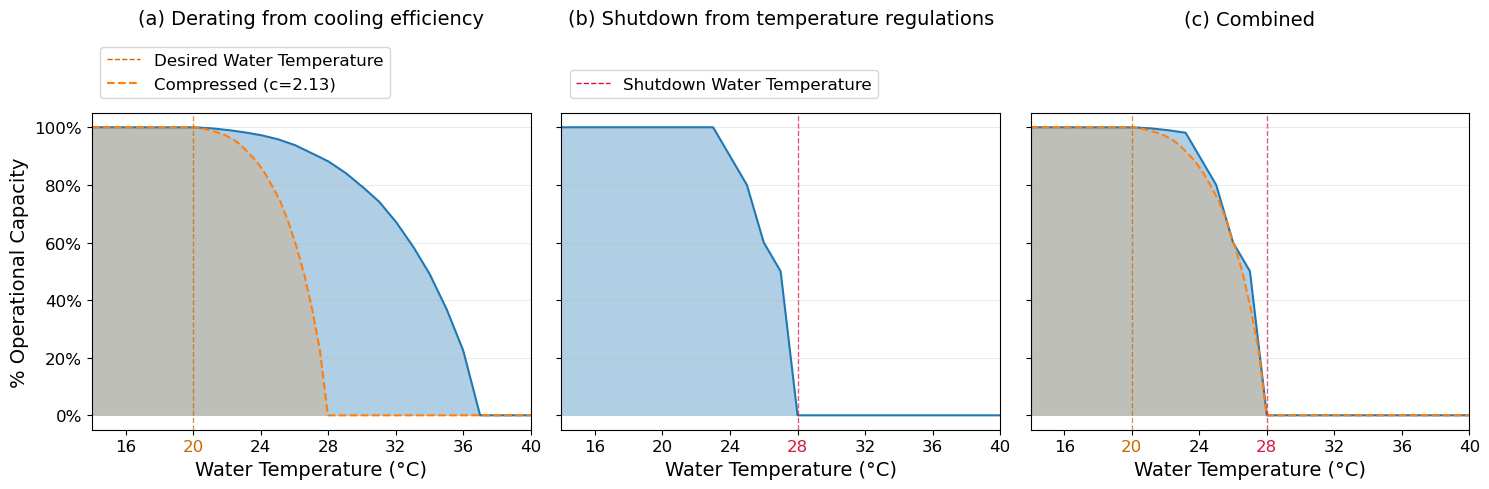

In [14]:
# from plot_damage import plot_damage_components

fig, axes = plot_damage_components(c=2.13)
plt.show()


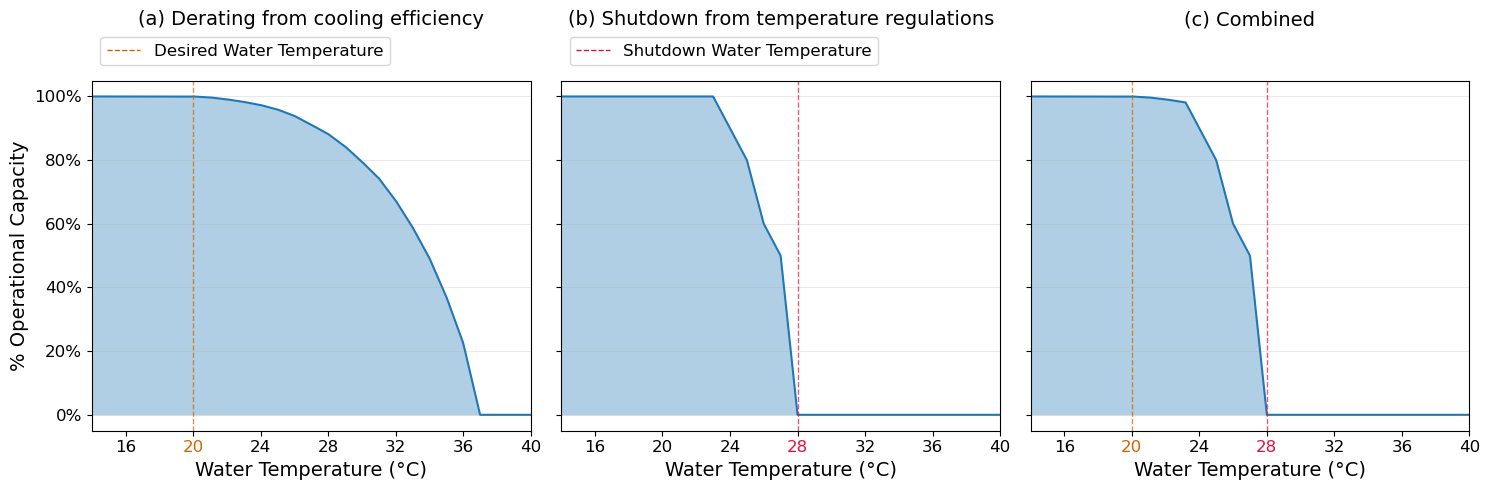

In [15]:
fig, axes = plot_damage_components(c=1)
plt.show()

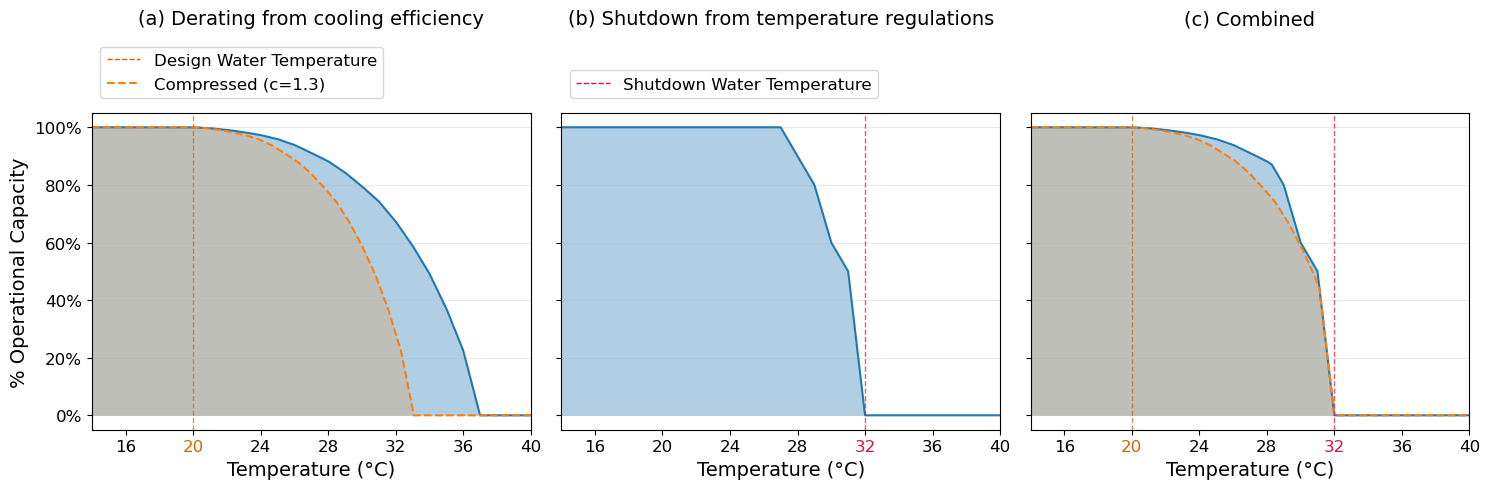

In [17]:
# from plot_damage import plot_damage_components

fig, axes = plot_damage_components(c=1.3, swt_c = 32)
plt.show()


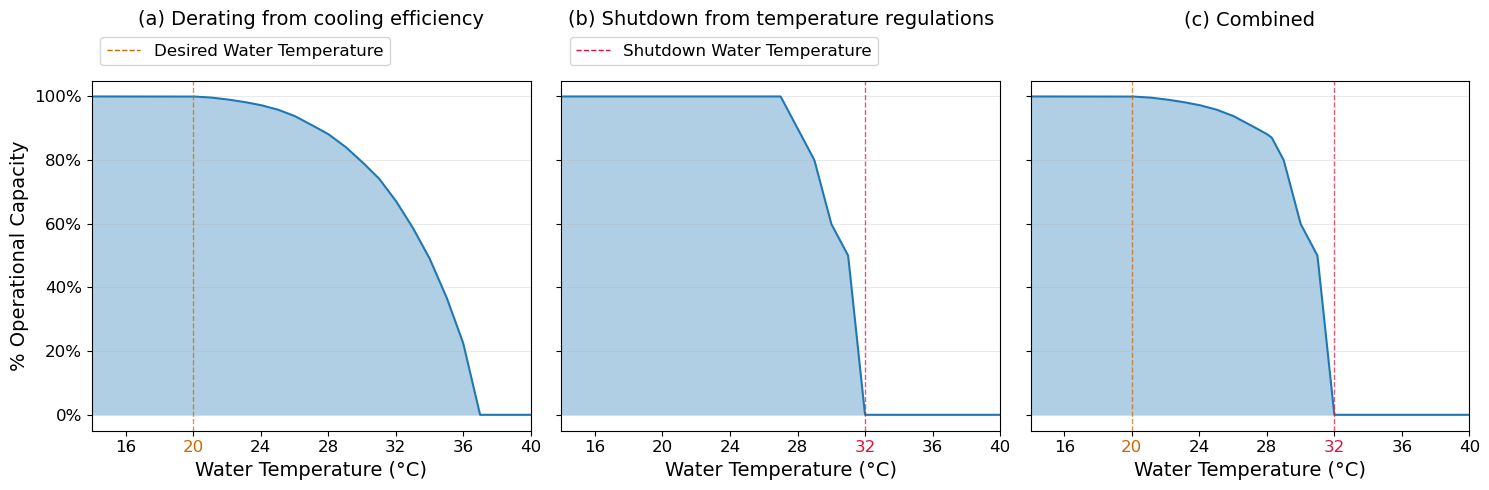

In [16]:
fig, axes = plot_damage_components(c=1, swt_c = 32)
plt.show()